In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import pandas as pd

In [2]:
# read in
folder = Path('./output/2025-11-26_15h51m25s_classif_grid5b_norms_learnable')

# subfolders = ['t1','t2','t3']
# dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
# test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

dev = pd.read_csv(folder/'dev.csv')
test = pd.read_csv(folder/'test.csv')

# get confs
config_names = dev['config'].unique().tolist()
confs = ConfigLookup(
    keys=['norm_class','learnable'],
    configs=config_names,
    path=folder,
    save=True
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

In [3]:
test

,norm_class,learnable,config,trial,metric,value
0,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,loss,1.607260
1,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,accuracy,0.068571
2,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,precision,0.013714
3,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,recall,0.200000
4,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,f1,0.025668
...,...,...,...,...,...,...
835,zNBVST,True,normclassZNBVST_normkwargsLearnableTrue,9,precision,0.718493
836,zNBVST,True,normclassZNBVST_normkwargsLearnableTrue,9,recall,0.692003
837,zNBVST,True,normclassZNBVST_normkwargsLearnableTrue,9,f1,0.670305
838,zNBVST,True,normclassZNBVST_normkwargsLearnableTrue,9,auroc,0.938259


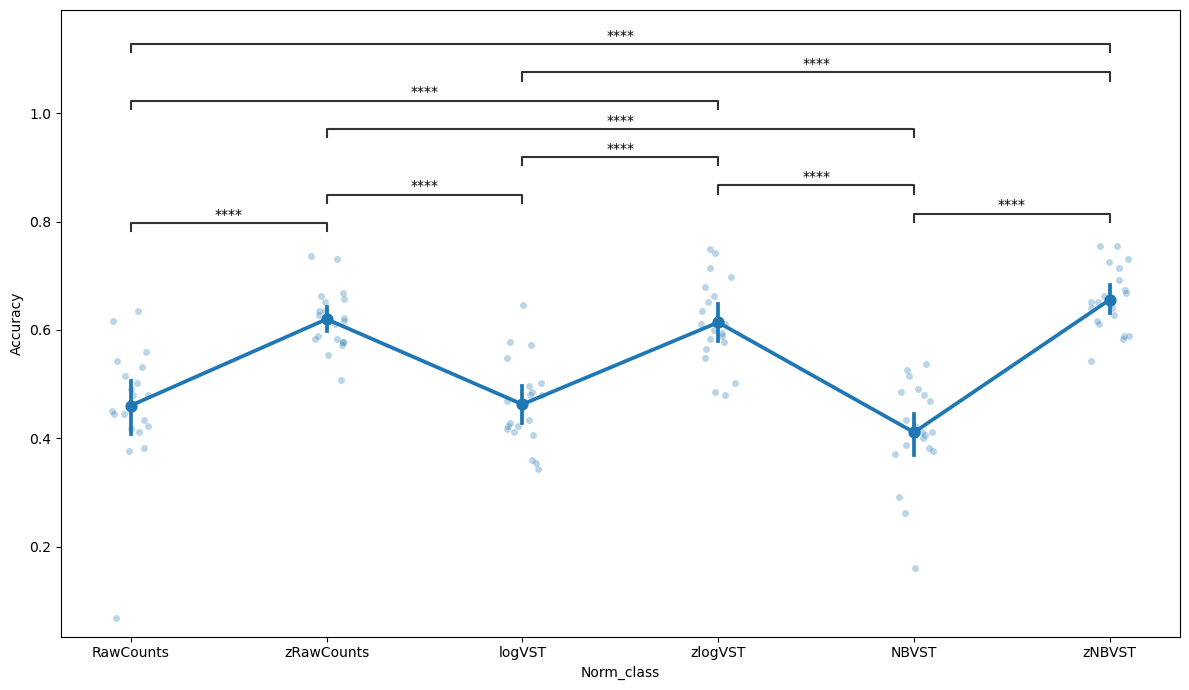

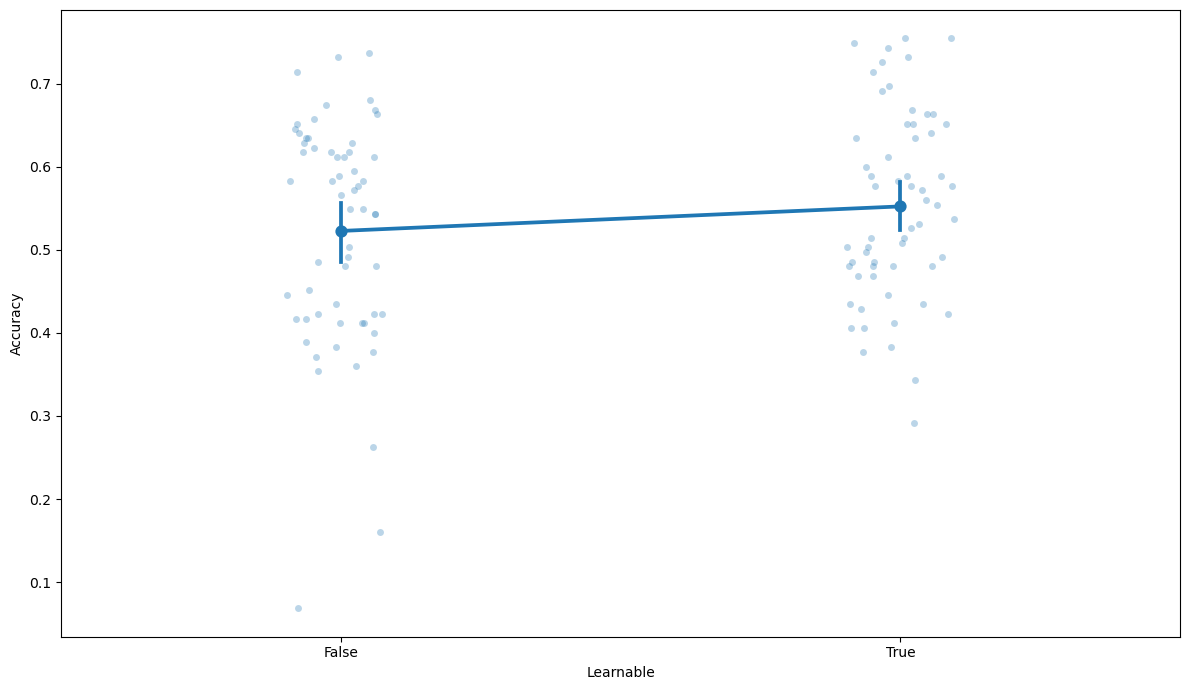

In [9]:
metric_x_point(
    df=test,
    cols=['norm_class', 'learnable'],
    metrics=['accuracy'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True,
)

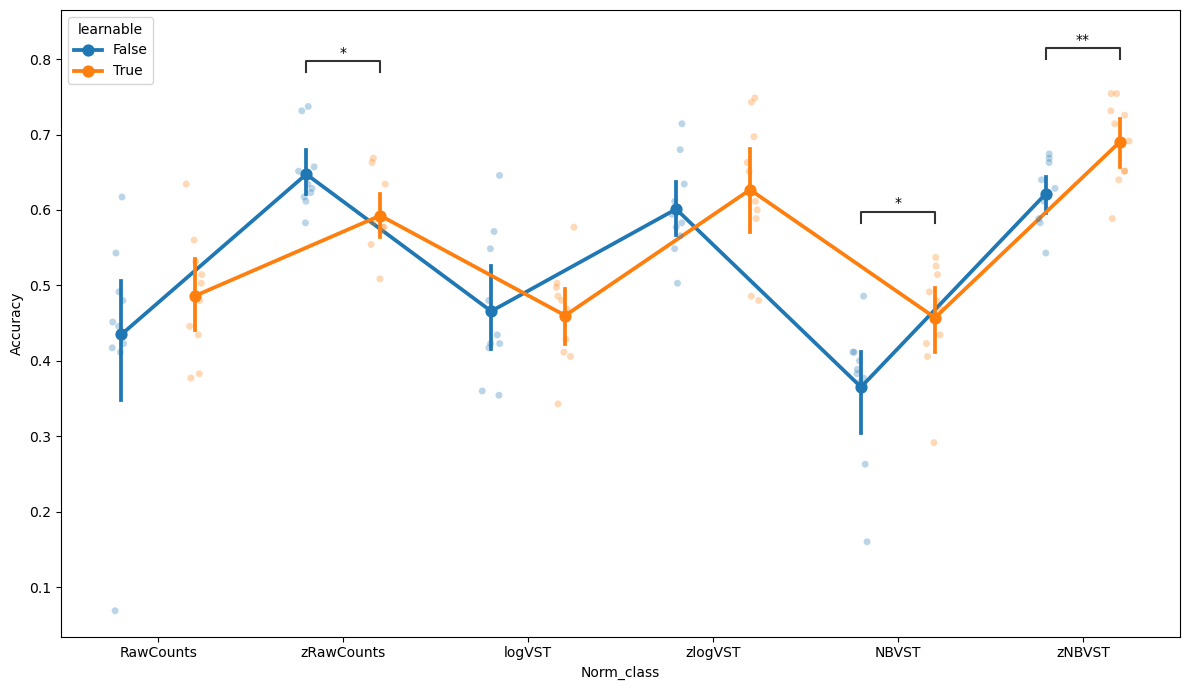

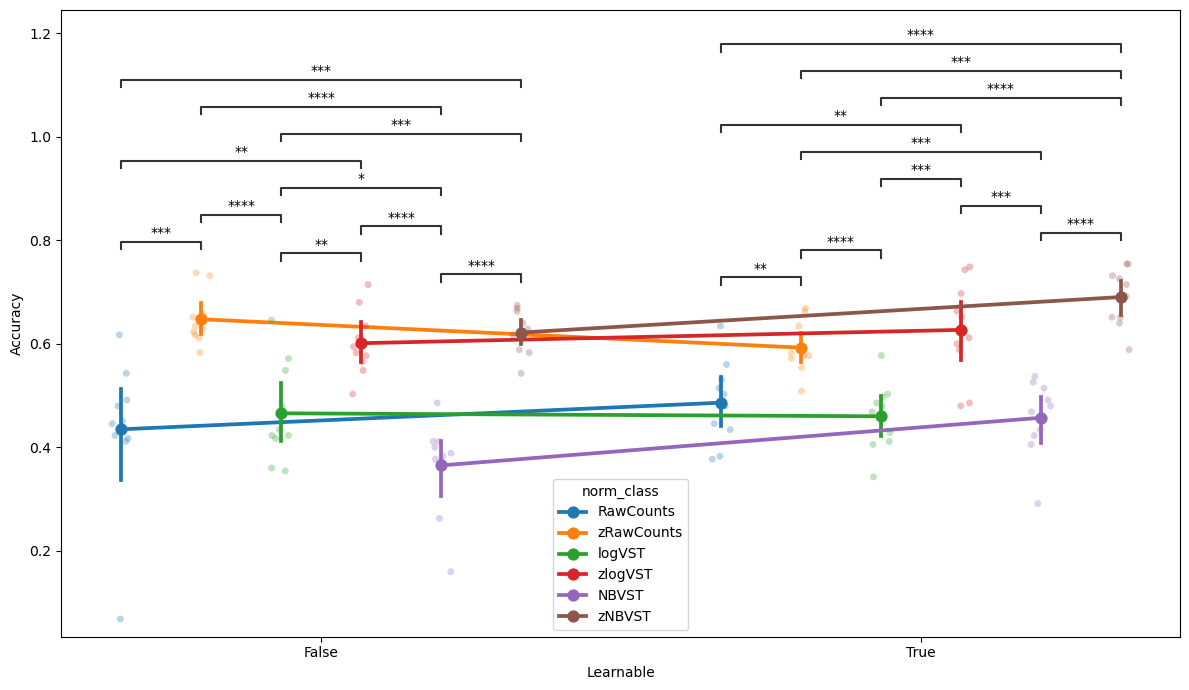

In [10]:
metric_x_point(
    df=test,
    cols=['norm_class', 'learnable'],
    metrics=['accuracy'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True,
    hue=True
)

In [6]:
# filt = test[test['norm_class'] != 'Normalizer'].copy()
filt = test.copy()
filt['z'] = test['norm_class'].str[0] == 'z'
filt['norm'] = filt['norm_class'].str.replace('|'.join(['z','VST']),'',regex=True)
filt

,norm_class,learnable,config,trial,metric,value,z,norm
0,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,loss,1.607260,False,RawCounts
1,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,accuracy,0.068571,False,RawCounts
2,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,precision,0.013714,False,RawCounts
3,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,recall,0.200000,False,RawCounts
4,RawCounts,False,normclassRawCounts_normkwargsLearnableFalse,0,f1,0.025668,False,RawCounts
...,...,...,...,...,...,...,...,...
835,zNBVST,True,normclassZNBVST_normkwargsLearnableTrue,9,precision,0.718493,True,NB
836,zNBVST,True,normclassZNBVST_normkwargsLearnableTrue,9,recall,0.692003,True,NB
837,zNBVST,True,normclassZNBVST_normkwargsLearnableTrue,9,f1,0.670305,True,NB
838,zNBVST,True,normclassZNBVST_normkwargsLearnableTrue,9,auroc,0.938259,True,NB


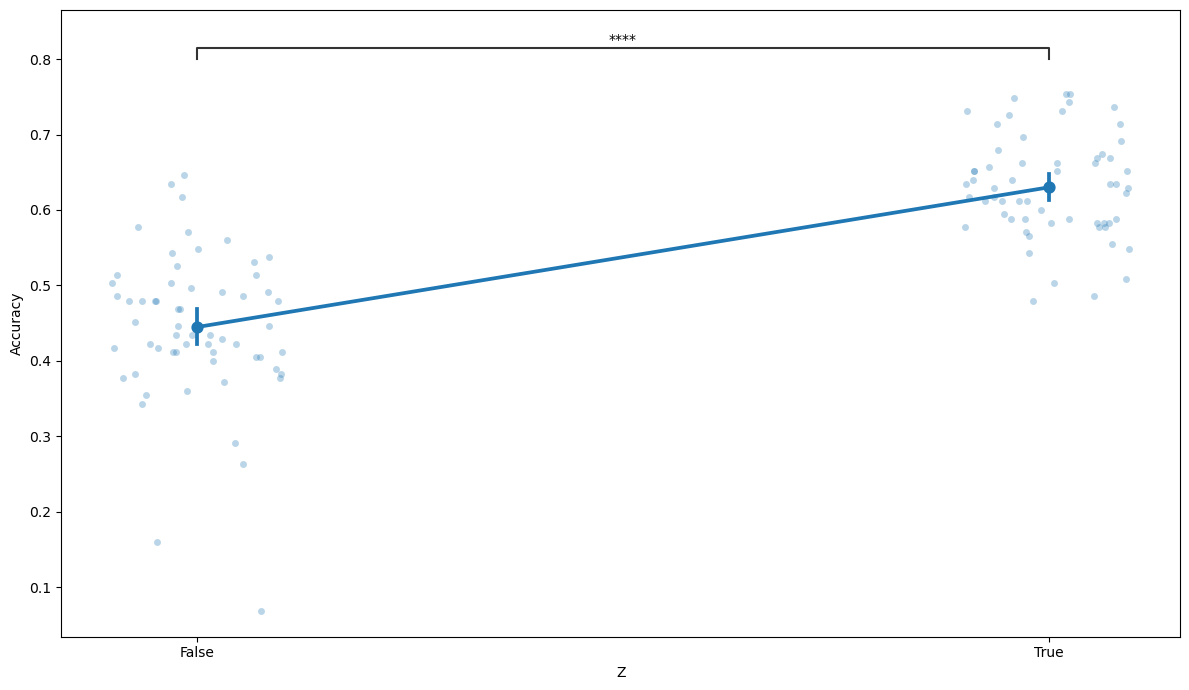

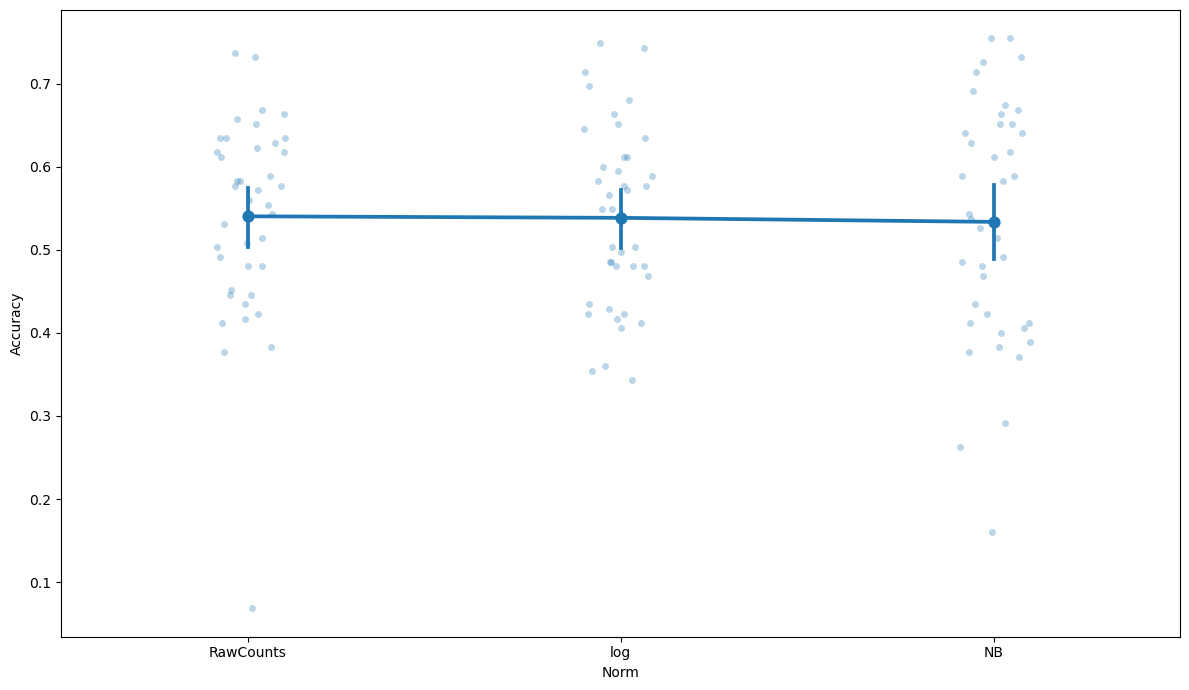

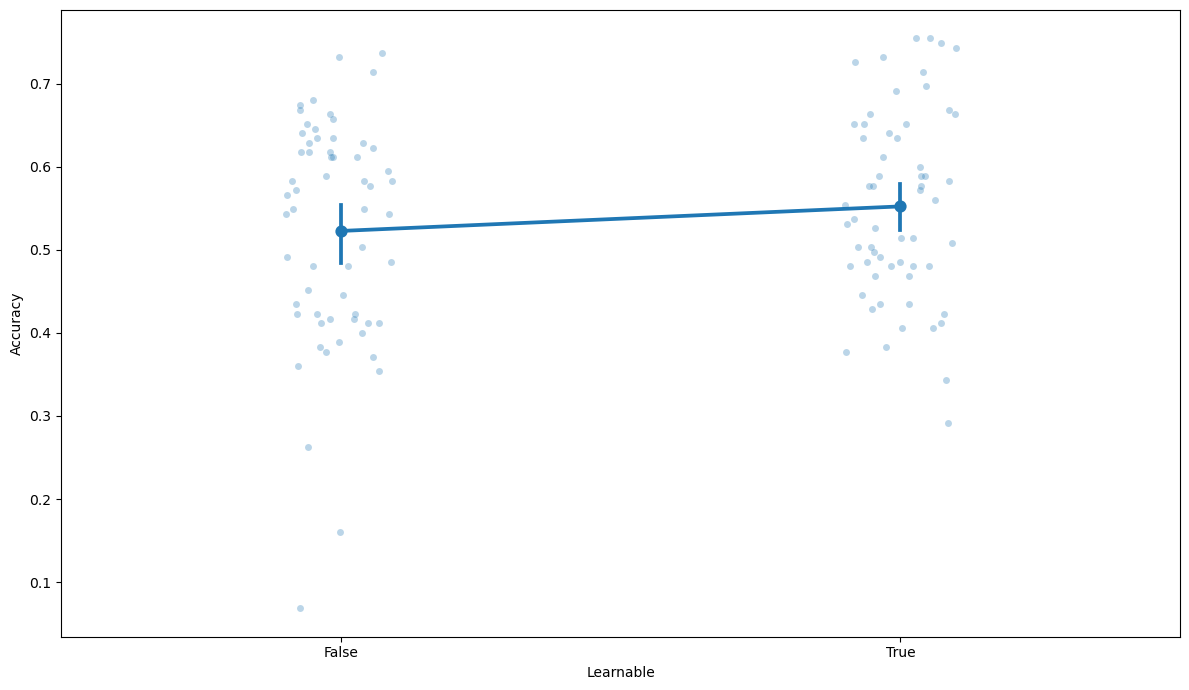

In [11]:
metric_x_point(
    df=filt,
    cols=['z','norm', 'learnable'],
    metrics=['accuracy'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True,
)

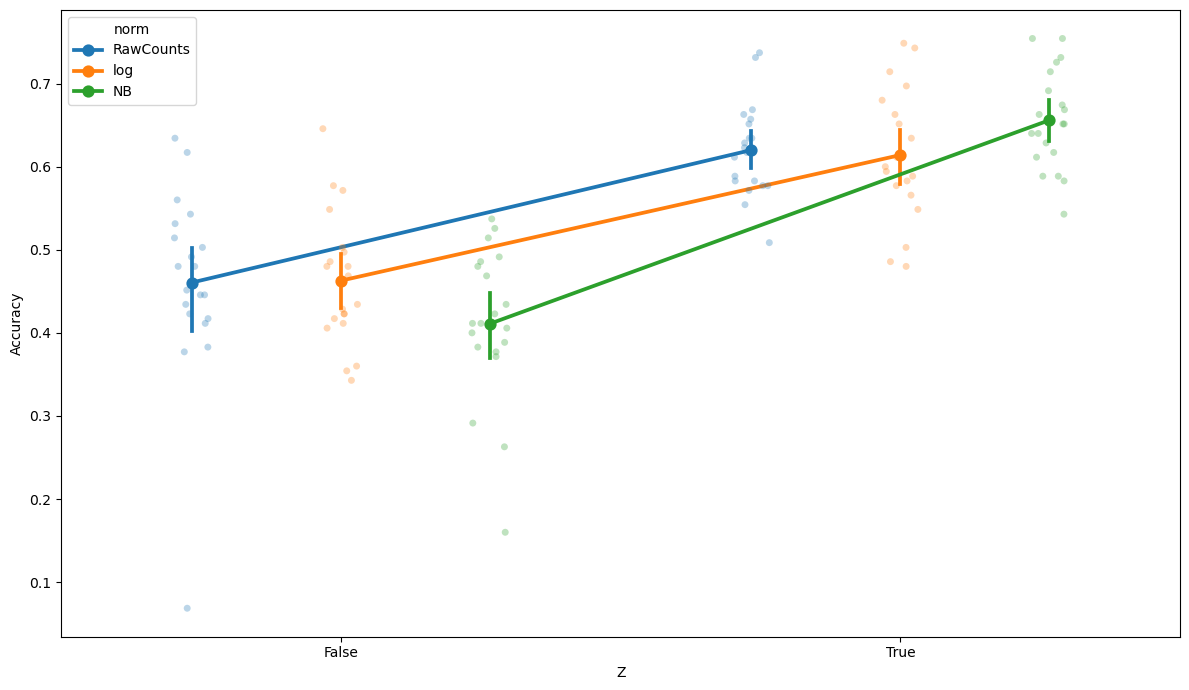

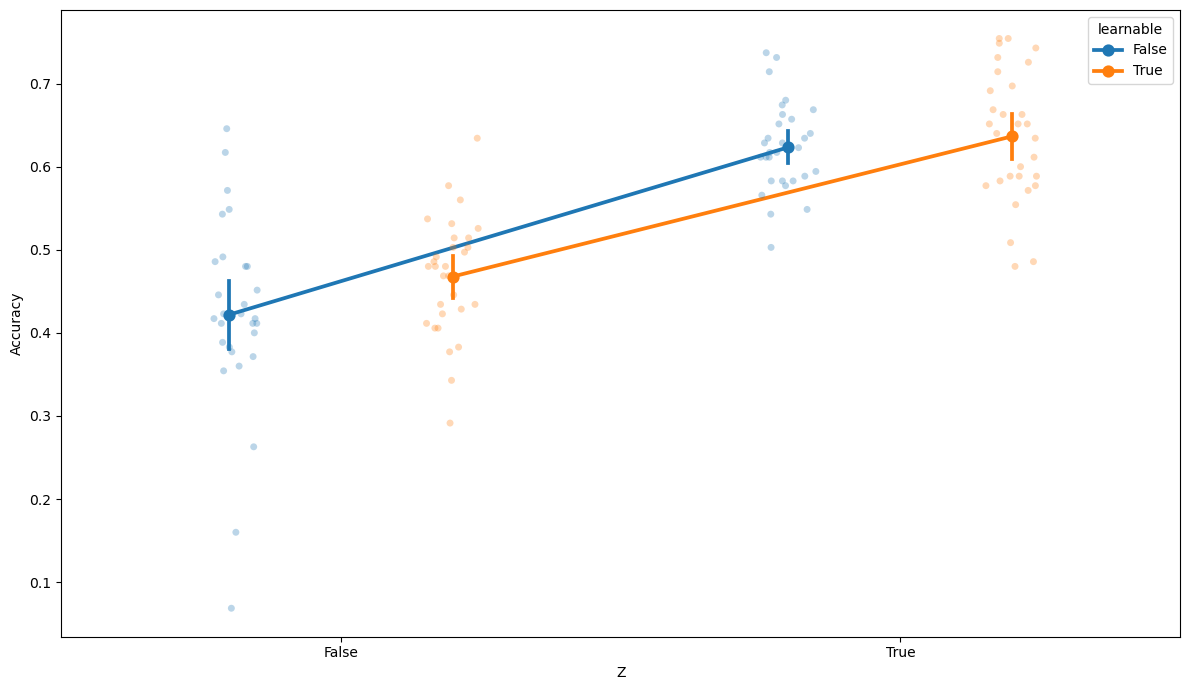

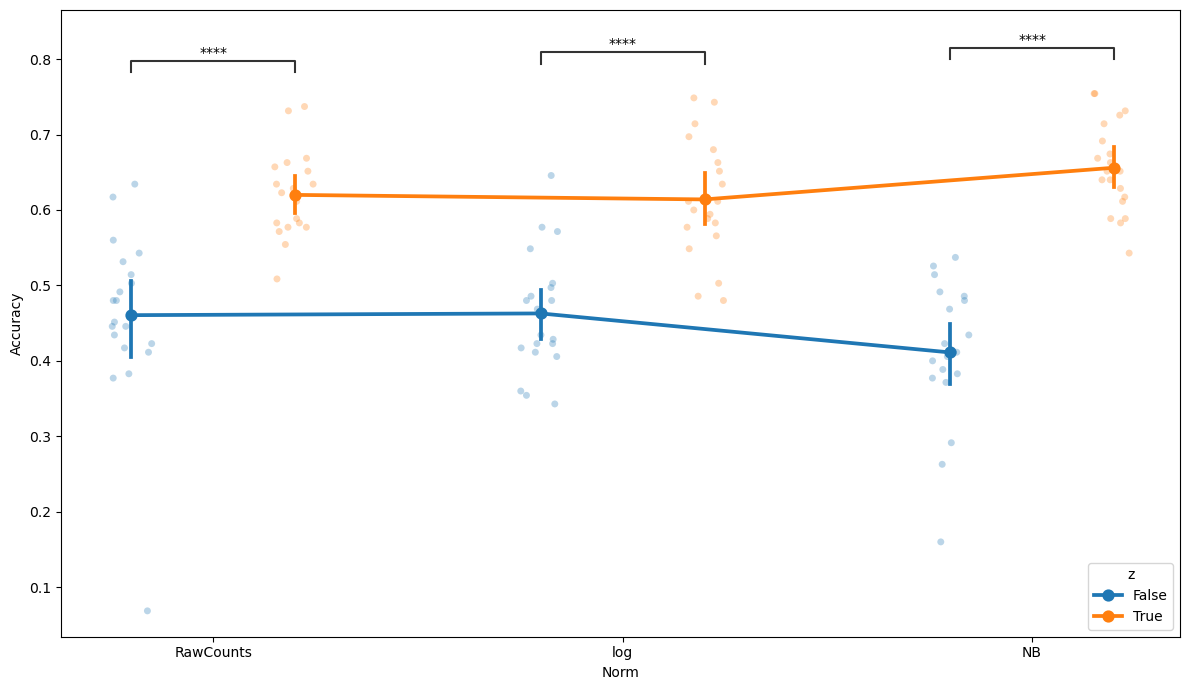

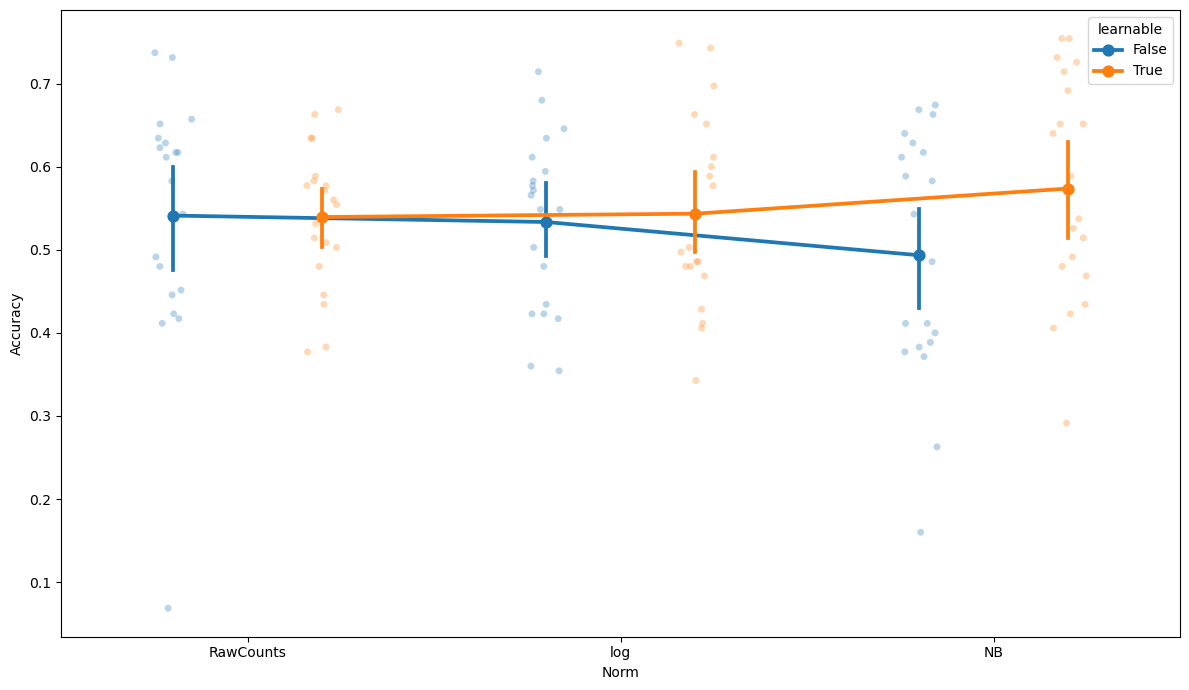

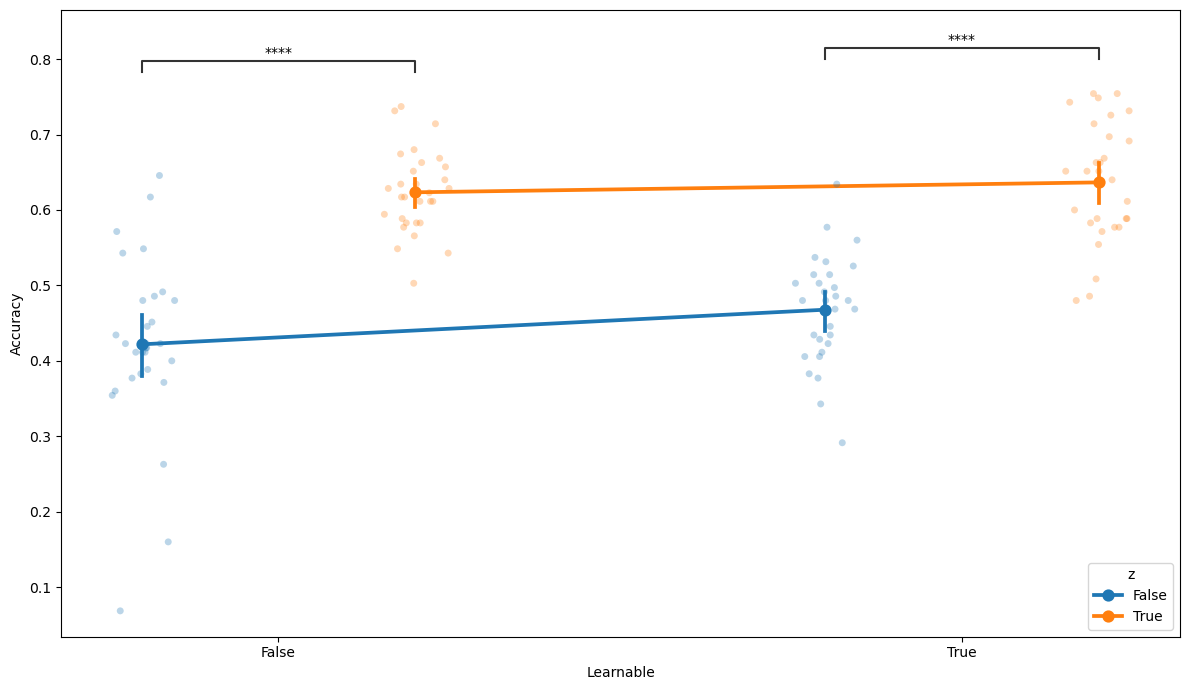

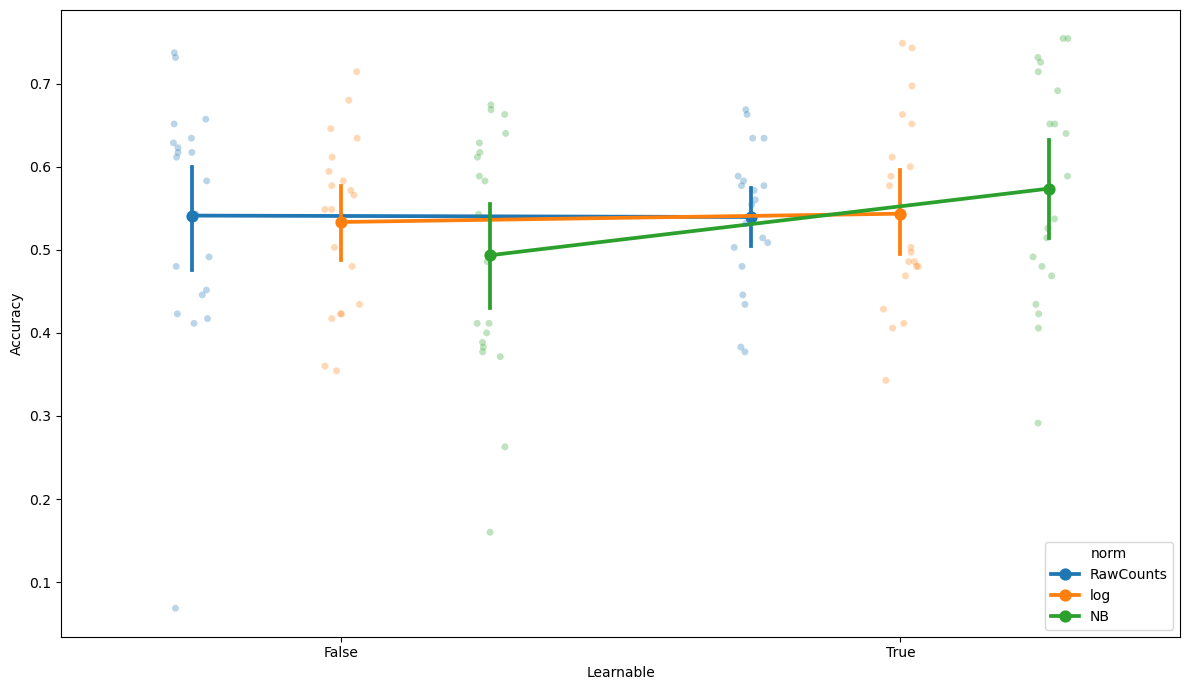

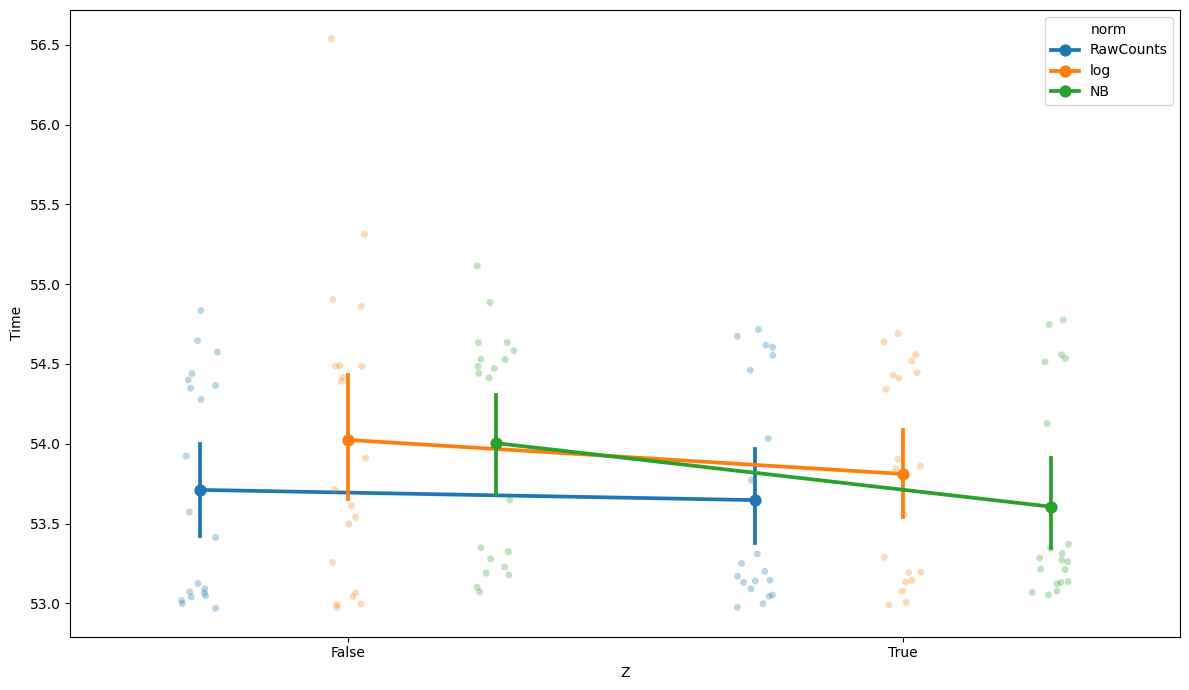

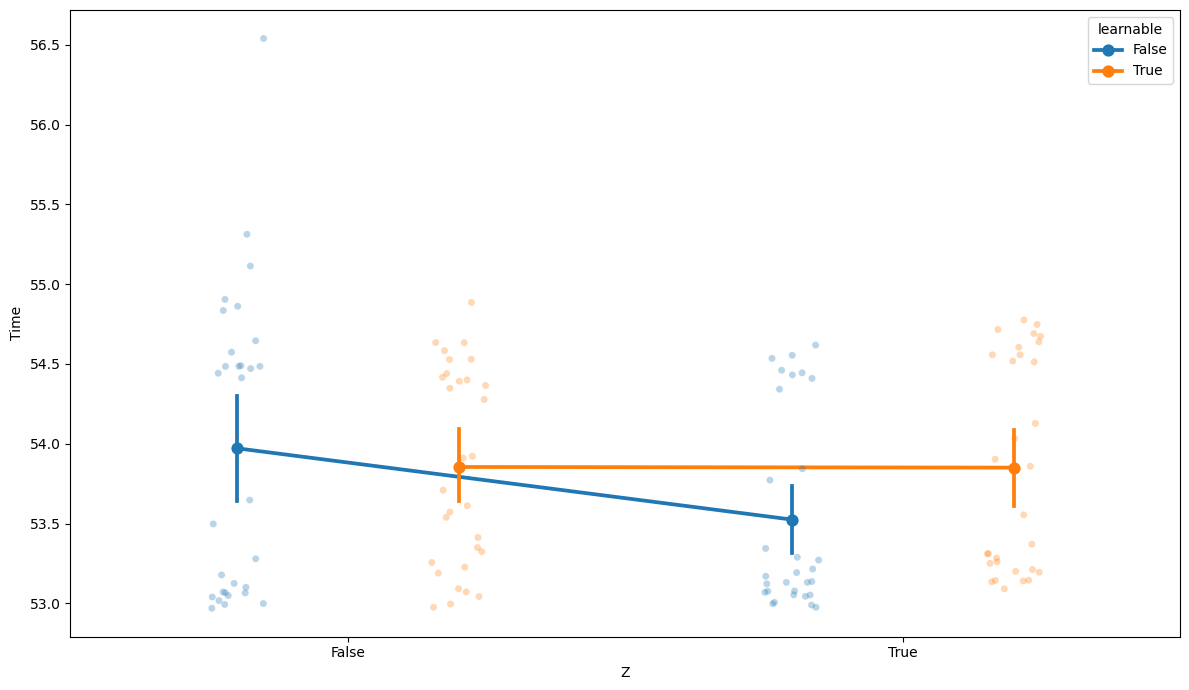

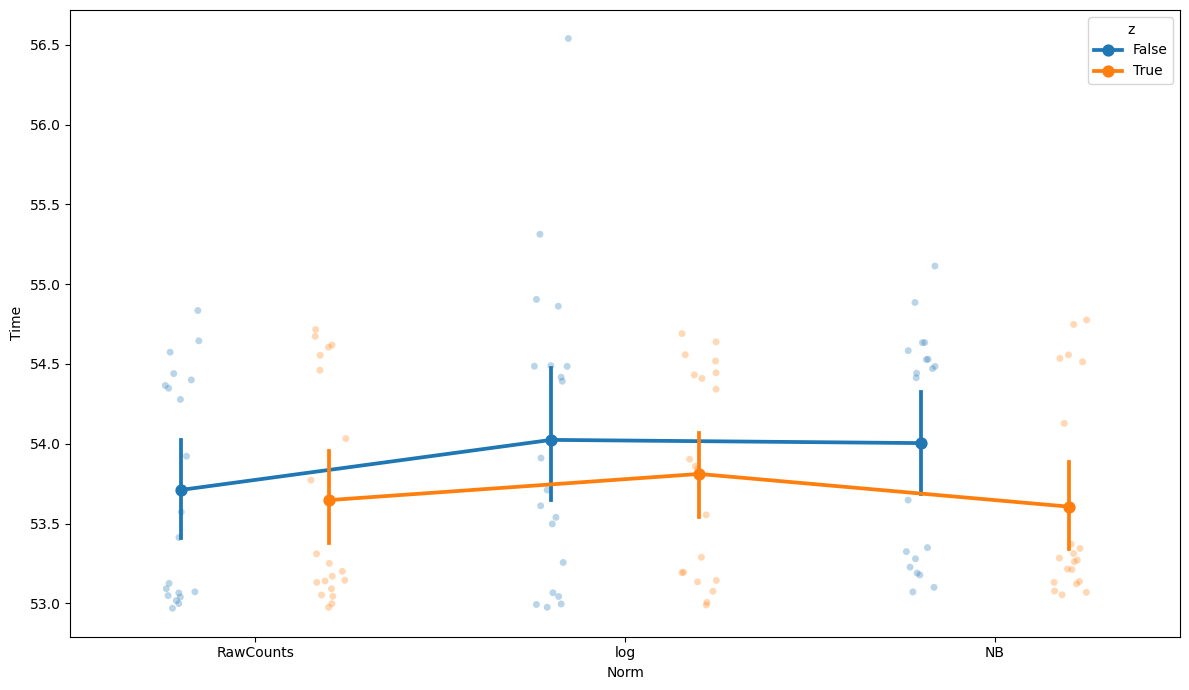

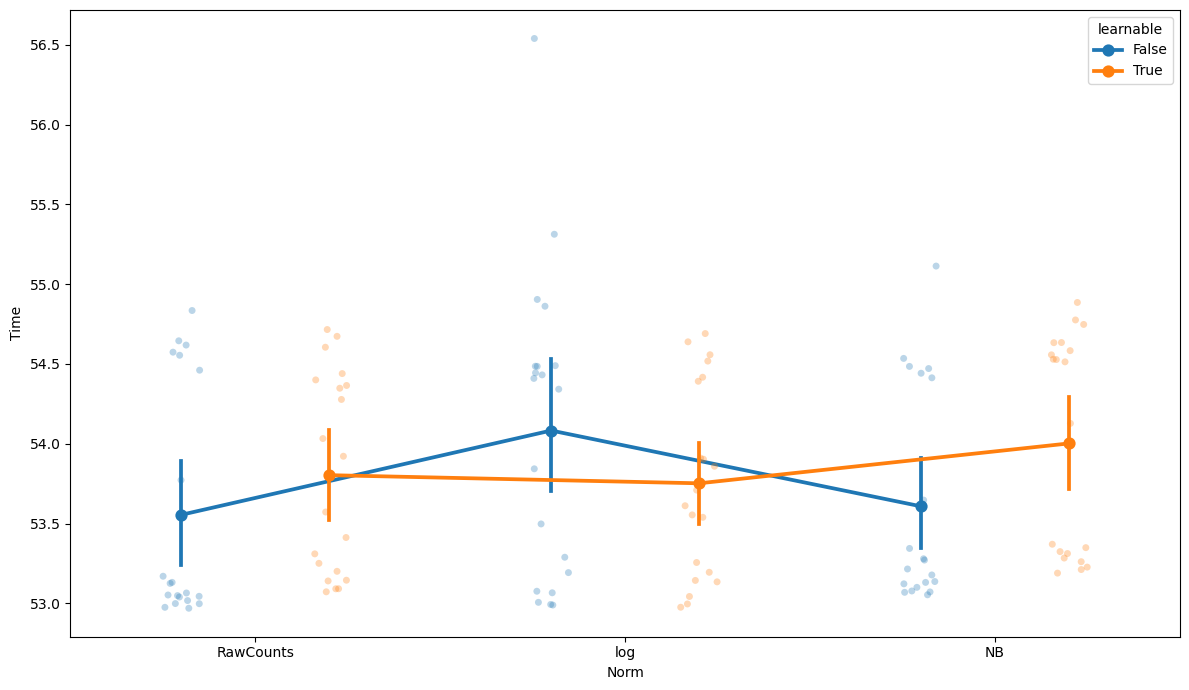

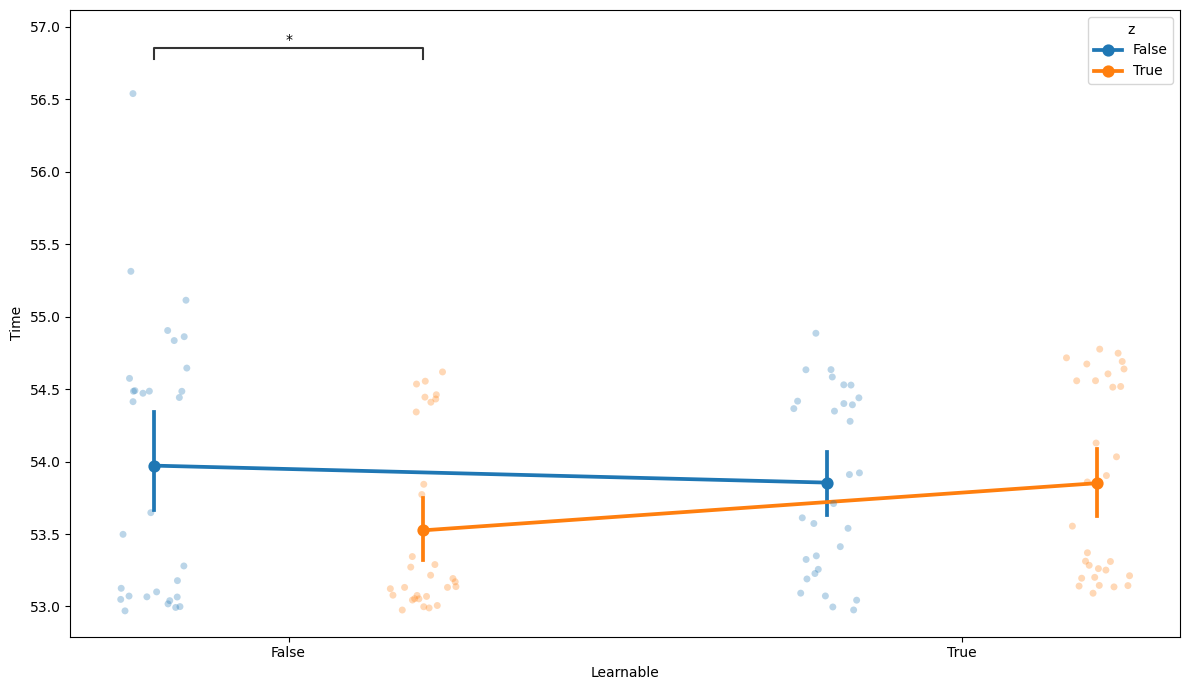

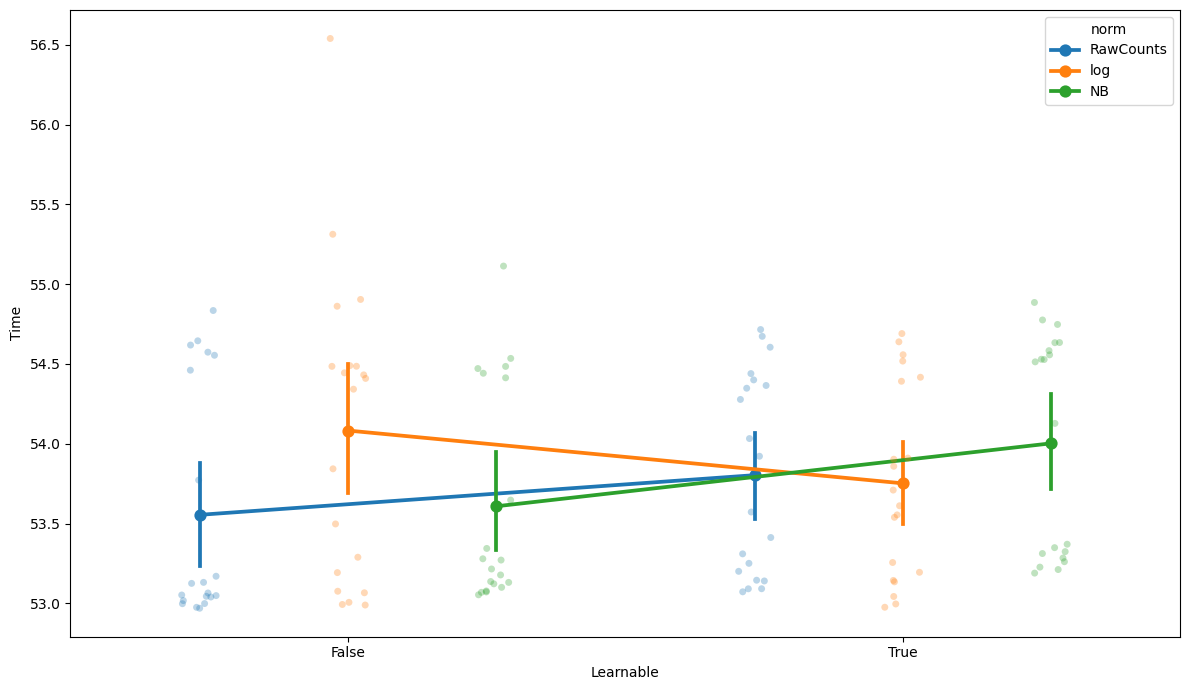

In [8]:
metric_x_point(
    df=filt,
    cols=['z','norm', 'learnable'],
    metrics=['accuracy', 'time'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True,
    hue=True,
)